
# **Social Media Addiction vs Productivity Dataset**

## Objetivo do projeto

Analisar como hábitos digitais, como uso de redes sociais e tempo de tela, se relacionam com foco e produtividade.

## O que vamos investigar

Vamos investigar se variáveis como tempo em redes sociais, tempo de tela, notificações, sono e horas de estudo influenciam a produtividade e o foco dos indivíduos.

##Carregamento e entendimento da base

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12

In [17]:
df = pd.read_csv("social_media_productivity_6000.csv")

# Mostrando as primeiras linhas do dataset
print(df.head())

    age  daily_screen_time  social_media_hours  study_hours  sleep_hours  \
0  21.0               5.95                2.81         2.61         6.99   
1  34.0               3.82                2.33         0.28         7.47   
2  29.0               3.57                1.64         5.21         6.34   
3  25.0              10.27                4.37         4.28         4.49   
4  22.0               2.42                1.60         3.67         6.34   

   notifications_per_day  focus_score addiction_level  productivity_score  
0                  283.0       100.00          Medium               28.49  
1                  266.0        93.65          Medium               18.54  
2                  137.0       100.00             Low               68.52  
3                  247.0        94.71          Medium               27.82  
4                   28.0       100.00             Low               51.09  


In [18]:
# Mostrando informações sobre o dataset
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   age                    5880 non-null   float64
 1   daily_screen_time      5880 non-null   float64
 2   social_media_hours     5880 non-null   float64
 3   study_hours            5880 non-null   float64
 4   sleep_hours            5880 non-null   float64
 5   notifications_per_day  5880 non-null   float64
 6   focus_score            5880 non-null   float64
 7   addiction_level        5880 non-null   object 
 8   productivity_score     5880 non-null   float64
dtypes: float64(8), object(1)
memory usage: 422.0+ KB
None


In [19]:
# Mostrando valores faltantes no dataset
print(df.isnull().sum())

age                      120
daily_screen_time        120
social_media_hours       120
study_hours              120
sleep_hours              120
notifications_per_day    120
focus_score              120
addiction_level          120
productivity_score       120
dtype: int64


In [20]:
# Mostrando estatísticas das colunas numéricas
print(df.describe())

               age  daily_screen_time  social_media_hours  study_hours  \
count  5880.000000        5880.000000         5880.000000  5880.000000   
mean     27.111395           6.923175            4.145915     4.069328   
std       7.268430           2.859055            2.155496     2.309472   
min      15.000000           2.000000            0.660000     0.000000   
25%      21.000000           4.470000            2.400000     2.120000   
50%      27.000000           6.860000            3.755000     4.115000   
75%      33.000000           9.360000            5.540000     6.030000   
max      39.000000          11.990000           10.660000     8.000000   

       sleep_hours  notifications_per_day  focus_score  productivity_score  
count  5880.000000            5880.000000  5880.000000         5880.000000  
mean      6.514270             159.781463    96.363531           37.614051  
std       1.434351              81.044666     7.416839           27.603251  
min       4.000000       

##Limpeza e preparação

O dataset possui 6000 registros e apresenta 120 valores ausentes em cada coluna, o que representa aproximadamente 2% da base. Como essa quantidade é pequena, optamos por remover os valores faltantes apenas nas colunas utilizadas em cada análise. Dessa forma, evitamos perder dados desnecessariamente e mantemos cada pergunta com o maior número possível de registros válidos.

## Perguntas e Respostas

### A. Redes sociais e produtividade

1. Mais tempo em redes sociais está associado a menor produtividade?

Correlação:  -0.5085459327301801
faixa_redes
0-1h    58.269515
1-2h    56.927910
2-3h    48.420305
3-4h    40.058673
4-5h    36.120185
5-6h    27.462416
6h+     16.355510
Name: productivity_score, dtype: float64


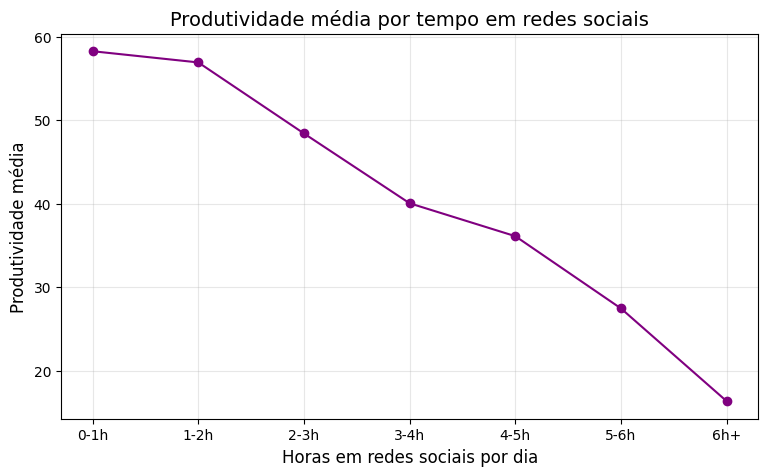

In [21]:
# variáveis utilizadas: social_media_hours e productivity_score

df_p1 = df[["social_media_hours", "productivity_score"]].dropna().copy()

# calculando a correlação entre as variáveis
correlacao_p1 = df_p1["social_media_hours"].corr(df_p1["productivity_score"])
print("Correlação: ", correlacao_p1)

# valores positivos: diretamente proporcionais
# valores negativos: inversamente proporcionais

# criando faixas de tempo em redes sociais
bins = [0, 1, 2, 3, 4, 5, 6, 10]
labels = ["0-1h", "1-2h", "2-3h", "3-4h", "4-5h", "5-6h", "6h+"]

df_p1["faixa_redes"] = pd.cut(
    df_p1["social_media_hours"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

# calculando a produtividade média por faixa
media_p1 = df_p1.groupby("faixa_redes", observed=False)["productivity_score"].mean()
print(media_p1)

# plotando o gráfico
plt.plot(media_p1.index.astype(str), media_p1.values, marker="o", color="purple")

plt.xlabel("Horas em redes sociais por dia")
plt.ylabel("Produtividade média")
plt.title("Produtividade média por tempo em redes sociais")
plt.grid(True, alpha=0.3)
plt.show()

2. Mais tempo total de tela por dia está associado a menor produtividade?

Correlação:  -0.41043231760870086
faixa_tela
0-2h      46.785714
2-4h      53.574300
4-6h      45.938912
6-8h      35.803406
8-10h     29.182945
10-12h    22.284454
Name: productivity_score, dtype: float64


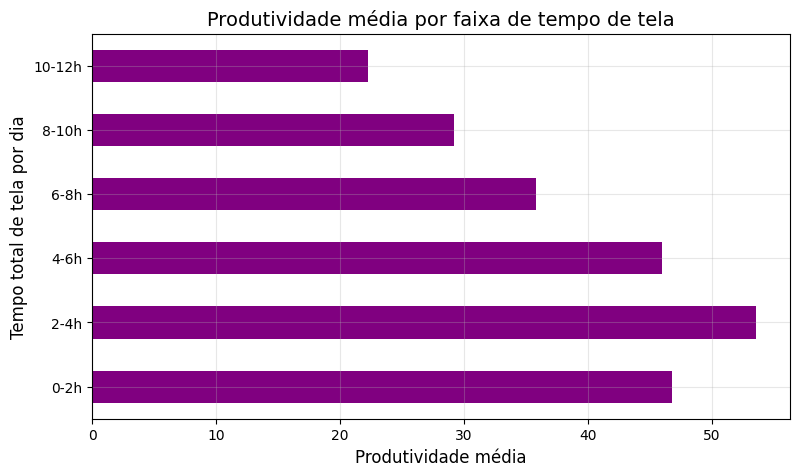

In [22]:
# variáveis utilizadas: daily_screen_time e productivity_score

df_p2 = df[["daily_screen_time", "productivity_score"]].dropna().copy()

# calculando a correlação entre as variáveis
correlacao_p2 = df_p2["daily_screen_time"].corr(df_p2["productivity_score"])
print("Correlação: ", correlacao_p2)

# criando faixas de tempo total de tela
bins = [0, 2, 4, 6, 8, 10, 12]
labels = ["0-2h", "2-4h", "4-6h", "6-8h", "8-10h", "10-12h"]

df_p2["faixa_tela"] = pd.cut(
    df_p2["daily_screen_time"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

# calculando a produtividade média por faixa
media_p2 = df_p2.groupby("faixa_tela", observed=False)["productivity_score"].mean()
print(media_p2)

# plotando o gráfico
media_p2.plot(kind="barh", color="purple")

plt.xlabel("Produtividade média")
plt.ylabel("Tempo total de tela por dia")
plt.title("Produtividade média por faixa de tempo de tela")
plt.show()

3. Mais tempo em redes sociais está associado a menor foco?

Correlação: -0.5975692867974848
faixa_redes
0-1h    99.922353
1-2h    99.782568
2-3h    99.465242
3-4h    98.616517
4-5h    97.576000
5-6h    94.944489
6h+     88.695225
Name: focus_score, dtype: float64


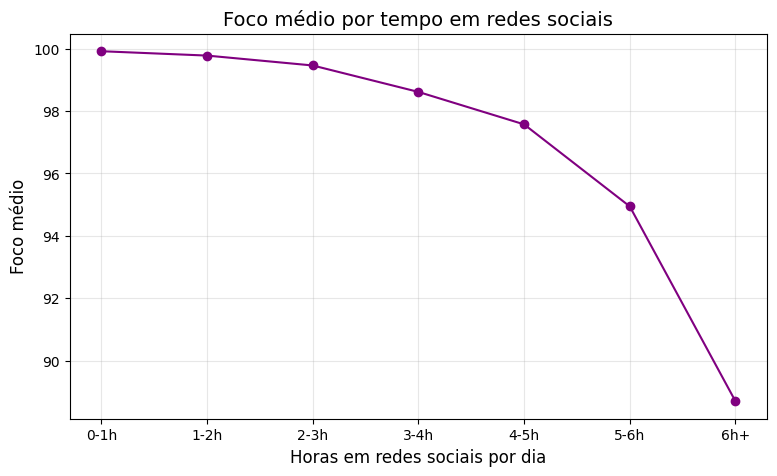

In [23]:
# variáveis utilizadas: social_media_hours e focus_score

df_p3 = df[["social_media_hours", "focus_score"]].dropna().copy()

# correlação
correlacao_p3 = df_p3["social_media_hours"].corr(df_p3["focus_score"])
print("Correlação:", correlacao_p3)

# Faixas de tempo em redes sociais
bins = [0, 1, 2, 3, 4, 5, 6, 10]
labels = ["0-1h", "1-2h", "2-3h", "3-4h", "4-5h", "5-6h", "6h+"]

df_p3["faixa_redes"] = pd.cut(
    df_p3["social_media_hours"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

# Média de foco por faixa
media_p3 = df_p3.groupby("faixa_redes", observed=False)["focus_score"].mean()
print(media_p3)

# plotando o gráfico
plt.plot(media_p3.index.astype(str), media_p3.values, marker="o", color="purple")

plt.xlabel("Horas em redes sociais por dia")
plt.ylabel("Foco médio")
plt.title("Foco médio por tempo em redes sociais")
plt.grid(True, alpha=0.3)
plt.show()

### B. Foco e Desempenho

4. Maior foco está associado a maior produtividade?

Correlação: 0.5721901806982287
faixa_foco
40-60      0.000000
60-75      0.110355
75-90      5.475097
90-100    43.437980
Name: productivity_score, dtype: float64


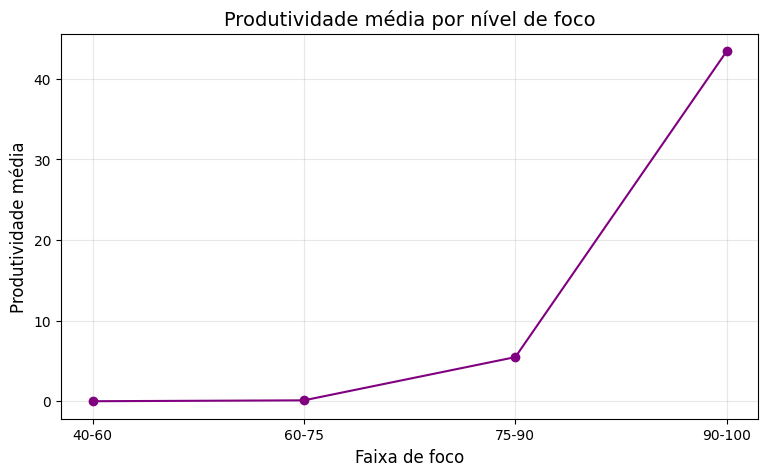


Conclusão: r=0.572 — maior foco está fortemente associado a maior produtividade.


In [24]:
# variáveis: focus_score e productivity_score
df_p4 = df[["focus_score", "productivity_score"]].dropna().copy()

# calculando a correlação entre as variáveis
correlacao_p4 = df_p4["focus_score"].corr(df_p4["productivity_score"])
print("Correlação:", correlacao_p4)

# criando faixas de foco
bins   = [40, 60, 75, 90, 100]
labels = ["40-60", "60-75", "75-90", "90-100"]

df_p4["faixa_foco"] = pd.cut(
    df_p4["focus_score"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

# calculando a produtividade média por faixa de foco
media_p4 = df_p4.groupby("faixa_foco", observed=False)["productivity_score"].mean()
print(media_p4)

# plotando o gráfico
plt.plot(media_p4.index.astype(str), media_p4.values, marker="o", color="purple")

plt.xlabel("Faixa de foco")
plt.ylabel("Produtividade média")
plt.title("Produtividade média por nível de foco")
plt.grid(True, alpha=0.3)
plt.show()

print(f"\nConclusão: r={correlacao_p4:.3f} — maior foco está fortemente associado a maior produtividade.")

5. Mais horas de estudo estão associadas a maior produtividade?

Correlação: 0.7389548822897508
faixa_estudo
0-1h     8.867908
1-2h    14.831433
2-3h    22.311413
3-4h    31.187763
4-5h    39.767622
5-6h    50.125745
6h+     64.719680
Name: productivity_score, dtype: float64


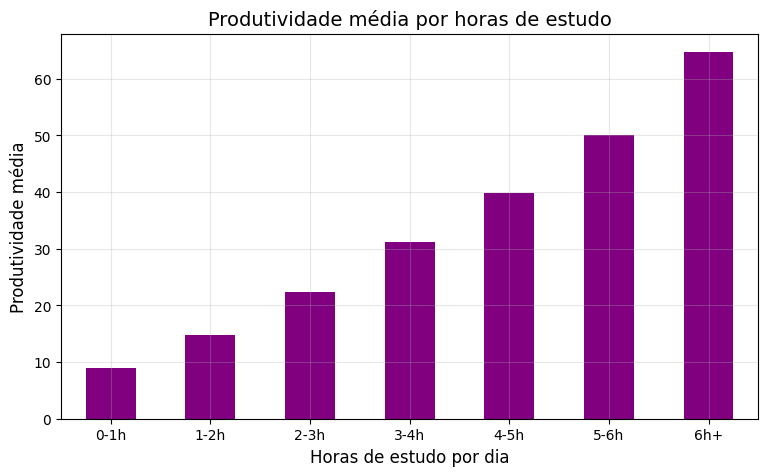


Conclusão: r=0.739 — horas de estudo têm a maior correlação positiva com produtividade no dataset.


In [25]:
# variáveis: study_hours e productivity_score
df_p5 = df[["study_hours", "productivity_score"]].dropna().copy()

# calculando a correlação entre as variáveis
correlacao_p5 = df_p5["study_hours"].corr(df_p5["productivity_score"])
print("Correlação:", correlacao_p5)

# criando faixas de horas de estudo
bins   = [0, 1, 2, 3, 4, 5, 6, 10]
labels = ["0-1h", "1-2h", "2-3h", "3-4h", "4-5h", "5-6h", "6h+"]

df_p5["faixa_estudo"] = pd.cut(
    df_p5["study_hours"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

# calculando a produtividade média por faixa de estudo
media_p5 = df_p5.groupby("faixa_estudo", observed=False)["productivity_score"].mean()
print(media_p5)

# plotando o gráfico
media_p5.plot(kind="bar", color="purple")

plt.xlabel("Horas de estudo por dia")
plt.ylabel("Produtividade média")
plt.title("Produtividade média por horas de estudo")
plt.xticks(rotation=0)
plt.show()

print(f"\nConclusão: r={correlacao_p5:.3f} — horas de estudo têm a maior correlação positiva com produtividade no dataset.")

6. Mais notificações por dia estão associadas a menor foco?

Correlação: -0.18212414925218756
faixa_notif
0-50       98.390631
50-100     97.700010
100-150    96.939359
150-200    95.993474
200+       94.922185
Name: focus_score, dtype: float64


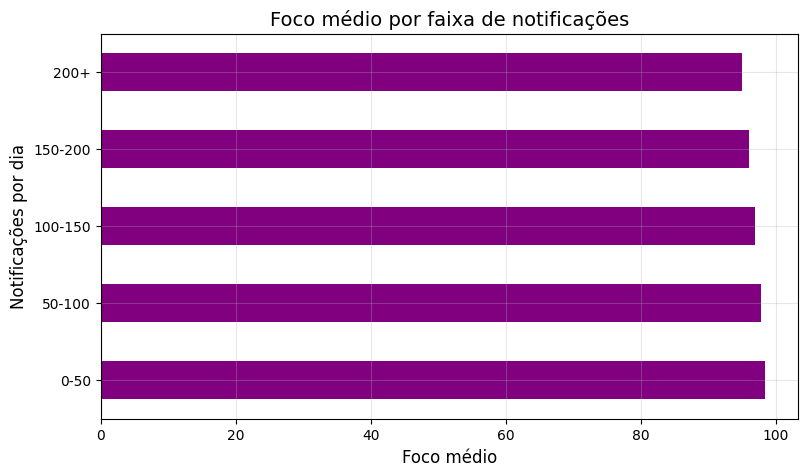


Conclusão: r=-0.182 — mais notificações estão associadas a menor foco, porém com efeito fraco.


In [26]:
# variáveis: notifications_per_day e focus_score
df_p6 = df[["notifications_per_day", "focus_score"]].dropna().copy()

# calculando a correlação entre as variáveis
correlacao_p6 = df_p6["notifications_per_day"].corr(df_p6["focus_score"])
print("Correlação:", correlacao_p6)

# criando faixas de notificações por dia
bins   = [0, 50, 100, 150, 200, 300]
labels = ["0-50", "50-100", "100-150", "150-200", "200+"]

df_p6["faixa_notif"] = pd.cut(
    df_p6["notifications_per_day"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

# calculando o foco médio por faixa de notificações
media_p6 = df_p6.groupby("faixa_notif", observed=False)["focus_score"].mean()
print(media_p6)

# plotando o gráfico
media_p6.plot(kind="barh", color="purple")

plt.xlabel("Foco médio")
plt.ylabel("Notificações por dia")
plt.title("Foco médio por faixa de notificações")
plt.show()

print(f"\nConclusão: r={correlacao_p6:.3f} — mais notificações estão associadas a menor foco, porém com efeito fraco.")

### C. Sono e hábitos

7. Mais horas de sono estão associadas a maior produtividade?

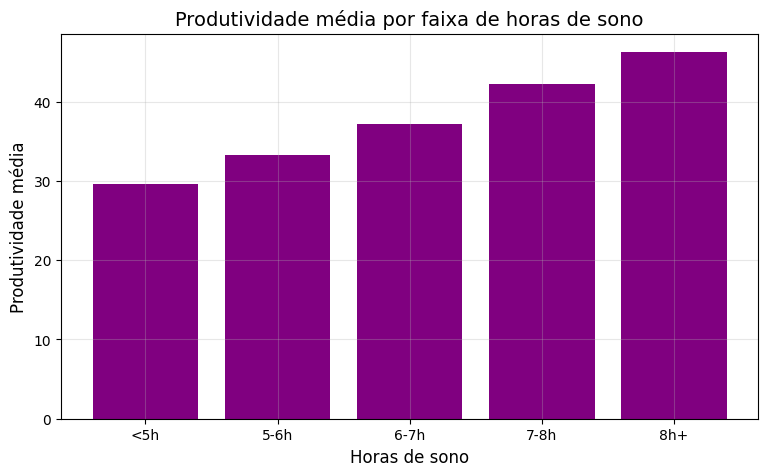

In [27]:
df_q7 = df.dropna(subset=['sleep_hours', 'productivity_score']).dropna().copy()
bins = [0, 5, 6, 7, 8, 13]
labels = ['<5h', '5-6h', '6-7h', '7-8h', '8h+']

df_q7['faixa_sono'] = pd.cut(df_q7['sleep_hours'], bins=bins, labels=labels)

media_prod = df_q7.groupby('faixa_sono', observed=False)['productivity_score'].mean()

plt.bar(media_prod.index, media_prod.values, color='purple')
plt.xlabel('Horas de sono')
plt.ylabel('Produtividade média')
plt.title('Produtividade média por faixa de horas de sono')
plt.show()

8. Quem passa mais tempo em redes sociais dorme menos?

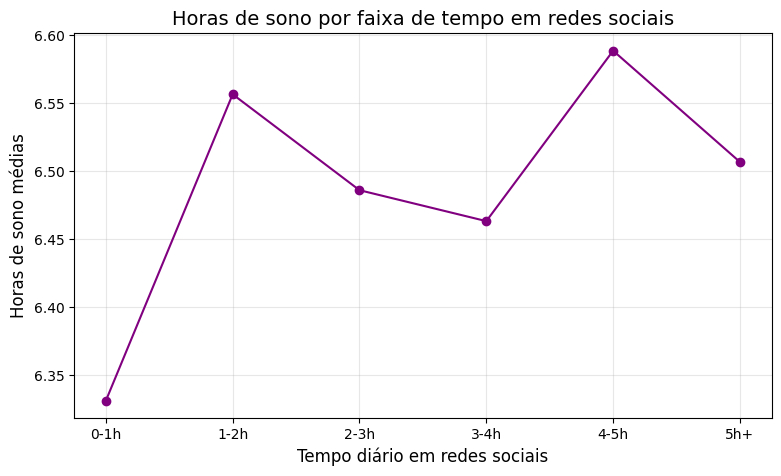

In [28]:
df_q8 = df.dropna(subset=['social_media_hours', 'sleep_hours']).dropna().copy()

bins = [0, 1, 2, 3, 4, 5, 15]
labels = ['0-1h', '1-2h', '2-3h', '3-4h', '4-5h', '5h+']

df_q8['faixa_social'] = pd.cut(df_q8['social_media_hours'], bins=bins, labels=labels)

media_sono = df_q8.groupby('faixa_social', observed=False)['sleep_hours'].mean()

plt.plot(media_sono.index, media_sono.values, 'o-', color="purple")
plt.xlabel('Tempo diário em redes sociais')
plt.ylabel('Horas de sono médias')
plt.title('Horas de sono por faixa de tempo em redes sociais')
plt.show()

### D. Perfis e grupos

9. Mais tempo total de tela está associado a maior nível de dependência digital (addiction_level)?

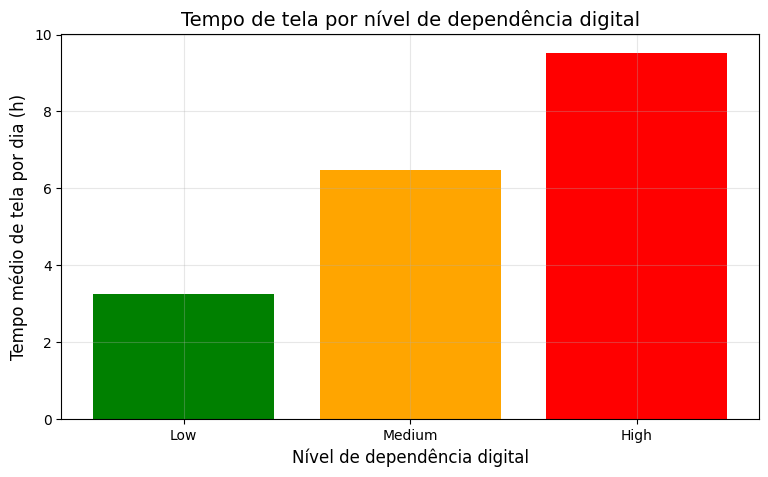

In [29]:
df_q9 = df.dropna(subset=['daily_screen_time', 'addiction_level']).dropna().copy()

media_tela = df_q9.groupby('addiction_level')['daily_screen_time'].mean()

ordem = ['Low', 'Medium', 'High']
media_tela = media_tela.reindex(ordem)

plt.bar(media_tela.index, media_tela.values, color=['green', 'orange', 'red'])
plt.xlabel('Nível de dependência digital')
plt.ylabel('Tempo médio de tela por dia (h)')
plt.title('Tempo de tela por nível de dependência digital')
plt.show()

10. Pessoas com maior nível de dependência digital têm menor produtividade?

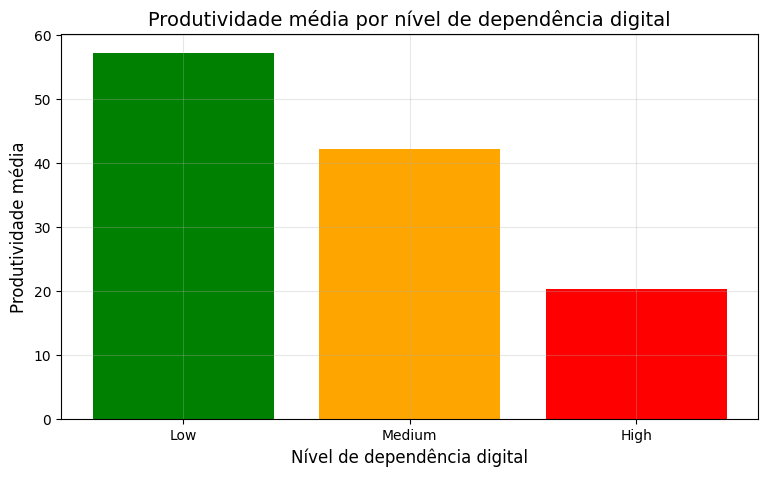

In [30]:
df_q10 = df.dropna(subset=['addiction_level', 'productivity_score']).dropna().copy()

media_prod = df_q10.groupby('addiction_level')['productivity_score'].mean()

ordem = ['Low', 'Medium', 'High']
media_prod = media_prod.reindex(ordem)

plt.bar(media_prod.index, media_prod.values, color=['green', 'orange', 'red'])
plt.xlabel('Nível de dependência digital')
plt.ylabel('Produtividade média')
plt.title('Produtividade média por nível de dependência digital')
plt.show()